# Bayesian parameter inference for the Lotka–Volterra ODE

We infer the four positive parameters of the deterministic Lotka–Volterra model,

$$\dot p_1=\alpha p_1-\beta p_1p_2,\qquad \dot p_2=-\gamma p_2+\delta p_1p_2,$$

using the experiment in Section 4.4 of [Baptista et al. (2023)](https://arxiv.org/pdf/2006.06755). One NumPyro model built with `dynestyx` defines the posterior for MAP, variational inference, NUTS, and adaptive Metropolis.

The default run is intentionally notebook-sized. BFGS replaces learning-rate-sensitive first-order optimization for both MAP and full-covariance VI, while the two MCMC methods use the supported `MCMCInference` interface directly.

## Imports, numerical settings, and figure style

We work in $z=\log(\alpha,\beta,\gamma,\delta)$, which makes positivity automatic. Double precision is useful because the observation noise is only one percent.

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)

import arviz as az
import diffrax as dfx
import dynestyx as dsx
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta, AutoMultivariateNormal
from numpyro.infer.initialization import init_to_value

from dynestyx.inference.configs.mcmc import (
    AdaptiveMetropolisConfig,
    NUTSConfig,
)
from dynestyx.inference.mcmc import MCMCInference

We also set up a compact plotting style used throughout the notebook.

In [2]:
STYLE_COLORS = {
    "warm_red": "#E64B35",
    "teal": "#009E73",
    "muted_blue": "#56B4E9",
    "neutral_gray": "#5F5F5F",
    "light_gray": "#BDBDBD",
    "black": "#222222",
}

mpl.rcParams.update(
    {
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "dejavusans",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.9,
        "lines.linewidth": 2.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": False,
    }
)


def despine_curve_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")


## A `dynestyx` model and reproducible data

The paper uses $p(0)=(30,1)$, observations at $t=2,4,\ldots,18$, true parameters $u^*=(0.92,0.05,1.50,0.02)$, and independent log-normal observation noise with standard deviation $\sigma=0.01$ in log space. Both data generation and later posterior prediction use `dsx.simulate`.

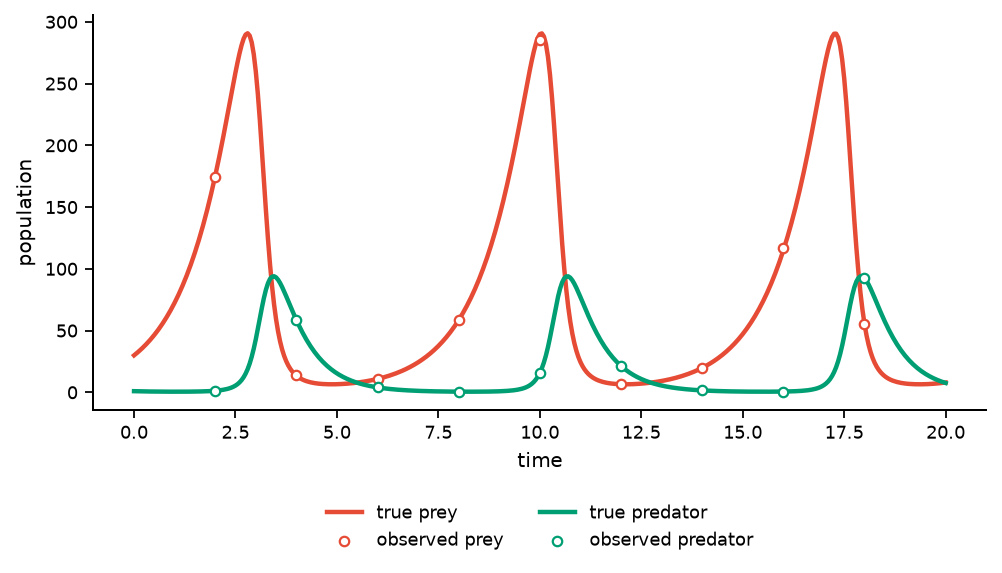

In [3]:
PARAMETER_NAMES = (r"$\alpha$", r"$\beta$", r"$\gamma$", r"$\delta$")
initial_state = jnp.array([30.0, 1.0])
initial_time = jnp.array([0.0])
observation_times = jnp.arange(2.0, 20.0, 2.0)
simulation_times = jnp.concatenate([initial_time, observation_times])
plot_times = jnp.linspace(0.0, 20.0, 401)

sigma_obs = 0.01
prior_mean = jnp.array([-0.125, -3.0, -0.125, -3.0])
prior_scale = jnp.sqrt(0.5) * jnp.ones(4)
log_parameter_prior = dist.Normal(prior_mean, prior_scale).to_event(1)
true_parameters = jnp.array([0.92, 0.05, 1.50, 0.02])


def make_dynamics(parameters):
    """Construct the deterministic Lotka–Volterra model at concrete parameters."""
    def drift(x, u, t):
        alpha, beta, gamma, delta = parameters
        prey, predator = x
        return jnp.array([
            alpha * prey - beta * prey * predator,
            -gamma * predator + delta * prey * predator,
        ])

    def observation_model(x, u, t):
        log_population = jnp.log(jnp.clip(x, min=1e-12))
        return dist.LogNormal(log_population, sigma_obs).to_event(1)

    return dsx.DynamicalModel(
        initial_condition=dist.Delta(initial_state, event_dim=1),
        state_evolution=dsx.ContinuousTimeStateEvolution(drift=drift),
        observation_model=observation_model,
        t0=None,
    )


def lotka_volterra_model(
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
    predict_times=None,
):
    """NumPyro model shared by optimization, VI, and MCMC."""
    log_parameters = numpyro.sample("log_parameters", log_parameter_prior)
    parameters = jnp.exp(log_parameters)
    numpyro.deterministic("parameters", parameters)
    return dsx.sample(
        "f",
        make_dynamics(parameters),
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
        state_path_params=initial_state,
    )


ODE_CONFIG = dsx.ODESimulatorConfig(
    solver=dfx.Tsit5(),
    stepsize_controller=dfx.PIDController(rtol=1e-5, atol=1e-7),
    adjoint=dfx.RecursiveCheckpointAdjoint(),
    dt0=0.05,
    max_steps=16_384,
    throw=False,
)

data = dsx.simulate(
    make_dynamics(true_parameters),
    rng_key=jr.PRNGKey(2026),
    predict_times=simulation_times,
    simulator_config=ODE_CONFIG,
)
observations = data.observations[0, 1:]

# The missing value at t=0 anchors the known initial state without adding data.
inference_times = simulation_times
inference_values = jnp.concatenate([
    jnp.full_like(observations[:1], jnp.nan),
    observations,
])
inference_builder = dsx.LatentPathBuilder(ode_simulator_config=ODE_CONFIG)

truth = dsx.simulate(
    make_dynamics(true_parameters),
    rng_key=jr.PRNGKey(2027),
    predict_times=plot_times,
    simulator_config=ODE_CONFIG,
).states[0]

fig, ax = plt.subplots(figsize=(7.2, 3.2))
for state, label, color in [
    (0, "prey", STYLE_COLORS["warm_red"]),
    (1, "predator", STYLE_COLORS["teal"]),
]:
    ax.plot(plot_times, truth[:, state], color=color, label=f"true {label}")
    ax.scatter(
        observation_times,
        observations[:, state],
        s=18,
        facecolor="white",
        edgecolor=color,
        linewidth=1.0,
        zorder=3,
        label=f"observed {label}",
    )
ax.set(xlabel="time", ylabel="population")
despine_curve_axis(ax)
ax.legend(ncols=2, loc="upper center", bbox_to_anchor=(0.5, -0.20))
fig.savefig("outputs/lotka_volterra_data.pdf")
fig.savefig("outputs/lotka_volterra_data.png", dpi=300)
plt.show()

## MAP with `AutoDelta` and BFGS

`AutoDelta` places all variational mass at one parameter value, so maximizing its ELBO is exactly maximizing the log posterior: MAP estimation.

NumPyro's `Minimize` optimizer runs BFGS to convergence in a single SVI update. Because BFGS is a local optimizer, we start it from the round-number rate guess $(1,0.05,1.5,0.02)$.

In [4]:
map_initial_log_parameters = jnp.log(
    jnp.array([1.0, 0.05, 1.5, 0.02])
)

map_guide = AutoDelta(
    lotka_volterra_model,
    init_loc_fn=init_to_value(
        values={"log_parameters": map_initial_log_parameters}
    ),
)
map_svi = SVI(
    lotka_volterra_model,
    map_guide,
    numpyro.optim.Minimize(
        method="BFGS",
        options={"maxiter": 100, "gtol": 1e-5},
    ),
    loss=Trace_ELBO(),
)

with inference_builder:
    t0 = time.perf_counter()
    map_state = map_svi.init(
        jr.PRNGKey(1),
        obs_times=inference_times,
        obs_values=inference_values,
    )
    map_state, map_loss = map_svi.update(
        map_state,
        obs_times=inference_times,
        obs_values=inference_values,
    )
    map_loss.block_until_ready()
    map_seconds = time.perf_counter() - t0

map_params = map_svi.get_params(map_state)
map_log_parameters = map_guide.median(map_params)["log_parameters"]

print(f"AutoDelta MAP: {map_seconds:.2f} s; negative ELBO={float(map_loss):.3f}")
print(f"{'parameter':<12} {'truth':>10} {'MAP':>10}")
for name, truth_value, map_value in zip(
    PARAMETER_NAMES,
    true_parameters,
    jnp.exp(map_log_parameters),
):
    print(f"{name:<12} {float(truth_value):10.5f} {float(map_value):10.5f}")

AutoDelta MAP: 9.99 s; negative ELBO=-5.029
parameter         truth        MAP
$\alpha$        0.92000    0.91690
$\beta$         0.05000    0.04974
$\gamma$        1.50000    1.50435
$\delta$        0.02000    0.02012


## NUTS through `MCMCInference`

NUTS adapts its step size and mass matrix during warmup. We initialize all four chains at the MAP and retain their chain structure for $\hat R$ and ESS diagnostics.

In [5]:
num_chains = 4
nuts_warmup = 250
nuts_samples_per_chain = 250
mcmc_init = init_to_value(values={"log_parameters": map_log_parameters})

nuts_inference = MCMCInference(
    mcmc_config=NUTSConfig(
        num_samples=nuts_samples_per_chain,
        num_warmup=nuts_warmup,
        num_chains=num_chains,
        mcmc_source="blackjax",
        init_strategy=mcmc_init,
        target_acceptance_rate=0.85,
    ),
    model=lotka_volterra_model,
)

with inference_builder:
    t0 = time.perf_counter()
    nuts_posterior = nuts_inference.run(
        jr.PRNGKey(10),
        inference_times,
        inference_values,
    )
    nuts_posterior["log_parameters"].block_until_ready()
    nuts_seconds = time.perf_counter() - t0

nuts_log_parameters = nuts_posterior["log_parameters"]
nuts_sampler_diagnostics = nuts_inference.get_diagnostics()

print(
    f"NUTS: {nuts_seconds:.2f} s, "
    f"mean acceptance={float(nuts_sampler_diagnostics['mean_acceptance_rate'].mean()):.3f}, "
    f"divergences={int(nuts_sampler_diagnostics['num_divergences'].sum())}"
)

NUTS: 41.00 s, mean acceptance=0.943, divergences=0


## Adaptive Metropolis through `MCMCInference`

Adaptive Metropolis performs scalar random-walk updates in the unconstrained parameter coordinates. During warmup, each proposal scale adapts toward an acceptance rate of 0.44; the scales are frozen before retained sampling begins. Componentwise updates are inexpensive, but the strong posterior correlation requires more retained draws than NUTS.

In [6]:
adaptive_warmup = 2_000
adaptive_samples_per_chain = 40_000

adaptive_inference = MCMCInference(
    mcmc_config=AdaptiveMetropolisConfig(
        num_samples=adaptive_samples_per_chain,
        num_warmup=adaptive_warmup,
        num_chains=num_chains,
        init_strategy=mcmc_init,
        initial_proposal_scale=0.001,
    ),
    model=lotka_volterra_model,
)

with inference_builder:
    t0 = time.perf_counter()
    adaptive_posterior = adaptive_inference.run(
        jr.PRNGKey(120),
        inference_times,
        inference_values,
    )
    adaptive_posterior["log_parameters"].block_until_ready()
    adaptive_seconds = time.perf_counter() - t0

adaptive_log_parameters = adaptive_posterior["log_parameters"]
adaptive_sampler_diagnostics = adaptive_inference.get_diagnostics()
adaptive_acceptance_by_component = adaptive_sampler_diagnostics[
    "mean_acceptance_rate"
].mean(axis=0)

print(f"Adaptive Metropolis: {adaptive_seconds:.2f} s")
print("acceptance by component:", np.round(adaptive_acceptance_by_component, 3))
print(
    "median frozen proposal scale:",
    np.round(
        jnp.median(
            adaptive_sampler_diagnostics["final_proposal_scale"], axis=0
        ),
        5,
    ),
)

Adaptive Metropolis: 33.24 s
acceptance by component: [0.317      0.64000005 0.43100002 0.44300002]
median frozen proposal scale: [0.00101 0.00119 0.00127 0.0017 ]


## Full-covariance VI with BFGS

`AutoMultivariateNormal` learns a dense Gaussian directly in the original log-parameter coordinates, including every pairwise correlation. We initialize it at the MAP and optimize the ELBO with the same BFGS interface. A fixed batch of reparameterized particles makes the objective smooth and removes learning rates, update schedules, and convergence plots from the tutorial.

In [7]:
vi_particles = 8
vi_draws = 4_000

vi_guide = AutoMultivariateNormal(
    lotka_volterra_model,
    init_loc_fn=init_to_value(values={"log_parameters": map_log_parameters}),
    init_scale=0.005,
)
vi = SVI(
    lotka_volterra_model,
    vi_guide,
    numpyro.optim.Minimize(
        method="BFGS",
        options={"maxiter": 100, "gtol": 1e-4},
    ),
    loss=Trace_ELBO(
        num_particles=vi_particles,
        vectorize_particles=True,
    ),
)

with inference_builder:
    t0 = time.perf_counter()
    vi_state = vi.init(
        jr.PRNGKey(30),
        obs_times=inference_times,
        obs_values=inference_values,
    )
    vi_state, vi_loss = vi.update(
        vi_state,
        obs_times=inference_times,
        obs_values=inference_values,
    )
    vi_loss.block_until_ready()
    vi_seconds = time.perf_counter() - t0

vi_params = vi.get_params(vi_state)
vi_posterior = vi_guide.sample_posterior(
    jr.PRNGKey(31),
    vi_params,
    sample_shape=(vi_draws,),
)
vi_log_parameters = vi_posterior["log_parameters"]

print(
    f"Full-covariance VI: {vi_seconds:.2f} s; "
    f"negative ELBO={float(vi_loss):.3f}"
)

Full-covariance VI: 14.50 s; negative ELBO=15.691


## Diagnostics, cost, and posterior summaries

NUTS and adaptive Metropolis report bulk ESS and $\hat R$ from their retained chains. VI draws are independent draws from an approximation, so an MCMC ESS would not measure approximation quality and is intentionally omitted. Timings include first compilation of each inference path.

In [8]:
nuts_parameters_physical = np.exp(np.asarray(nuts_log_parameters))
adaptive_parameters_physical = np.exp(np.asarray(adaptive_log_parameters))
vi_parameters_physical = np.exp(np.asarray(vi_log_parameters))


def mcmc_diagnostics(draws):
    idata = az.from_dict(
        posterior={
            name.strip("$\\"): draws[..., i]
            for i, name in enumerate(PARAMETER_NAMES)
        }
    )
    ess = az.ess(idata, method="bulk")
    rhat = az.rhat(idata)
    variable_names = list(idata.posterior.data_vars)
    min_ess = min(float(ess[name].values) for name in variable_names)
    max_rhat = max(float(rhat[name].values) for name in variable_names)
    return min_ess, max_rhat


nuts_min_ess, nuts_max_rhat = mcmc_diagnostics(nuts_parameters_physical)
adaptive_min_ess, adaptive_max_rhat = mcmc_diagnostics(
    adaptive_parameters_physical
)

diagnostic_rows = [
    (
        "NUTS",
        nuts_seconds,
        float(nuts_sampler_diagnostics["mean_acceptance_rate"].mean()),
        nuts_min_ess,
        nuts_max_rhat,
    ),
    (
        "adaptive Metropolis",
        adaptive_seconds,
        float(adaptive_sampler_diagnostics["mean_acceptance_rate"].mean()),
        adaptive_min_ess,
        adaptive_max_rhat,
    ),
]
print(
    f"{'method':<20} {'seconds':>9} {'accept':>9} "
    f"{'min ESS':>10} {'ESS/s':>10} {'max R-hat':>11}"
)
for method, seconds, acceptance, min_ess, max_rhat in diagnostic_rows:
    print(
        f"{method:<20} {seconds:9.2f} {acceptance:9.3f} "
        f"{min_ess:10.1f} {min_ess / seconds:10.1f} {max_rhat:11.3f}"
    )
print(
    f"{'full-covariance VI':<20} {vi_seconds:9.2f} {'n/a':>9} "
    f"{'n/a':>10} {'n/a':>10} {'n/a':>11}"
)

posterior_draws = {
    "NUTS": nuts_parameters_physical.reshape(-1, 4),
    "adaptive Metropolis": adaptive_parameters_physical.reshape(-1, 4),
    "full-covariance VI": vi_parameters_physical,
}

print()
print(
    f"{'parameter':<12} {'truth':>10} "
    + " ".join(f"{method + ' mean':>22}" for method in posterior_draws)
)
for i, name in enumerate(PARAMETER_NAMES):
    means = " ".join(
        f"{draws[:, i].mean():22.5f}" for draws in posterior_draws.values()
    )
    print(f"{name:<12} {float(true_parameters[i]):10.5f} {means}")

method                 seconds    accept    min ESS      ESS/s   max R-hat
NUTS                     41.00     0.943      240.7        5.9       1.014
adaptive Metropolis      33.24     0.458      233.9        7.0       1.019
full-covariance VI       14.50       n/a        n/a        n/a         n/a

parameter         truth              NUTS mean adaptive Metropolis mean full-covariance VI mean
$\alpha$        0.92000                0.91702                0.91686                0.91640
$\beta$         0.05000                0.04975                0.04972                0.04972
$\gamma$        1.50000                1.50419                1.50451                1.50578
$\delta$        0.02000                0.02012                0.02013                0.02013


## Marginal posterior comparison

The two MCMC samplers should agree up to Monte Carlo error. Full-covariance VI can represent the posterior's linear dependence directly in log-parameter space; the marginal comparison below shows how well its fitted location and scale agree with the sampling-based reference.

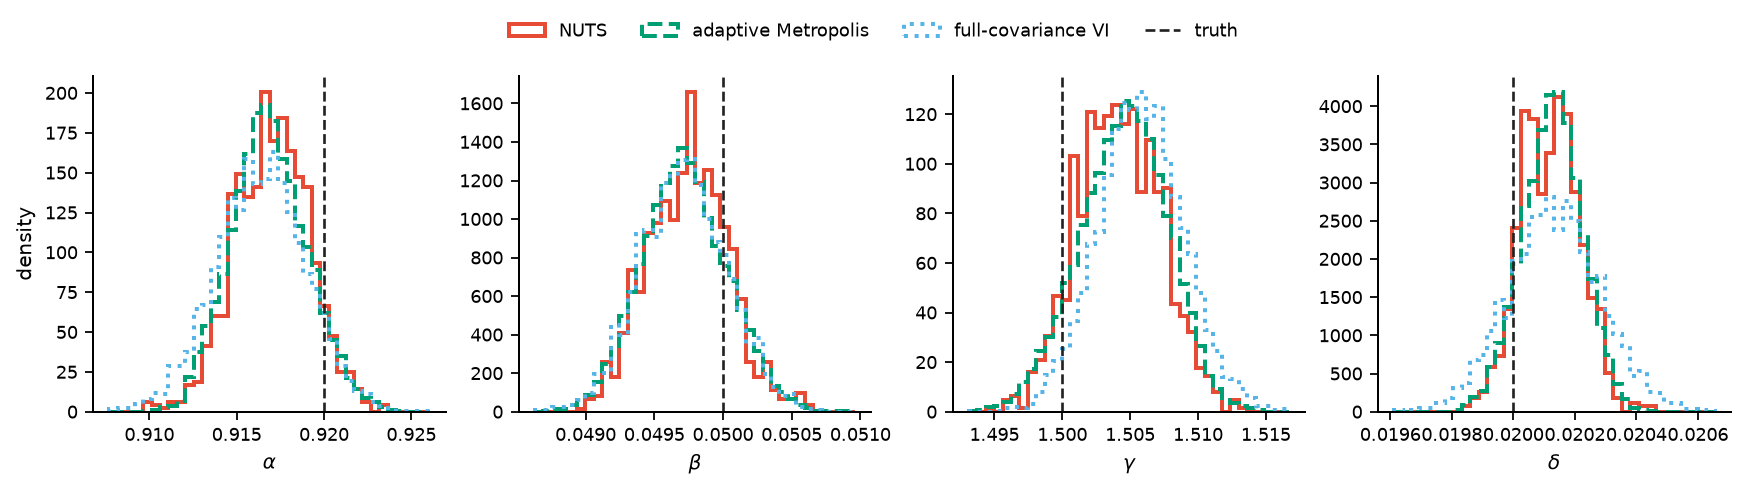

In [9]:
method_styles = {
    "NUTS": (STYLE_COLORS["warm_red"], "-"),
    "adaptive Metropolis": (STYLE_COLORS["teal"], "--"),
    "full-covariance VI": (STYLE_COLORS["muted_blue"], ":"),
}

fig, axes = plt.subplots(1, 4, figsize=(10.8, 3.0), constrained_layout=True)
fig.get_layout_engine().set(rect=(0.0, 0.0, 1.0, 0.86))
for i, (name, ax) in enumerate(zip(PARAMETER_NAMES, axes)):
    combined = np.concatenate([draws[:, i] for draws in posterior_draws.values()])
    bins = np.histogram_bin_edges(combined, bins=38)
    for method, draws in posterior_draws.items():
        color, linestyle = method_styles[method]
        ax.hist(
            draws[:, i],
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            linestyle=linestyle,
            linewidth=1.8,
            label=method,
        )
    ax.axvline(
        float(true_parameters[i]),
        color=STYLE_COLORS["black"],
        linestyle="--",
        linewidth=1.2,
        label="truth",
    )
    ax.set(xlabel=name, ylabel="density" if i == 0 else None)
    despine_curve_axis(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=4, loc="upper center", bbox_to_anchor=(0.5, 0.99))
fig.savefig("outputs/lotka_volterra_parameter_marginals.pdf")
fig.savefig("outputs/lotka_volterra_parameter_marginals.png", dpi=300)
plt.show()

## Corner plots of posterior dependence

The diagonal panels show the marginal histograms, while each lower-triangular panel shows a bivariate histogram for one parameter pair; the upper triangle is intentionally left blank. Separate corner plots for full-covariance VI and NUTS make the learned tilted dependence directly visible without combining two methods inside one matrix. Both figures use equal numbers of draws and shared parameter limits so their geometry can be compared panel by panel.

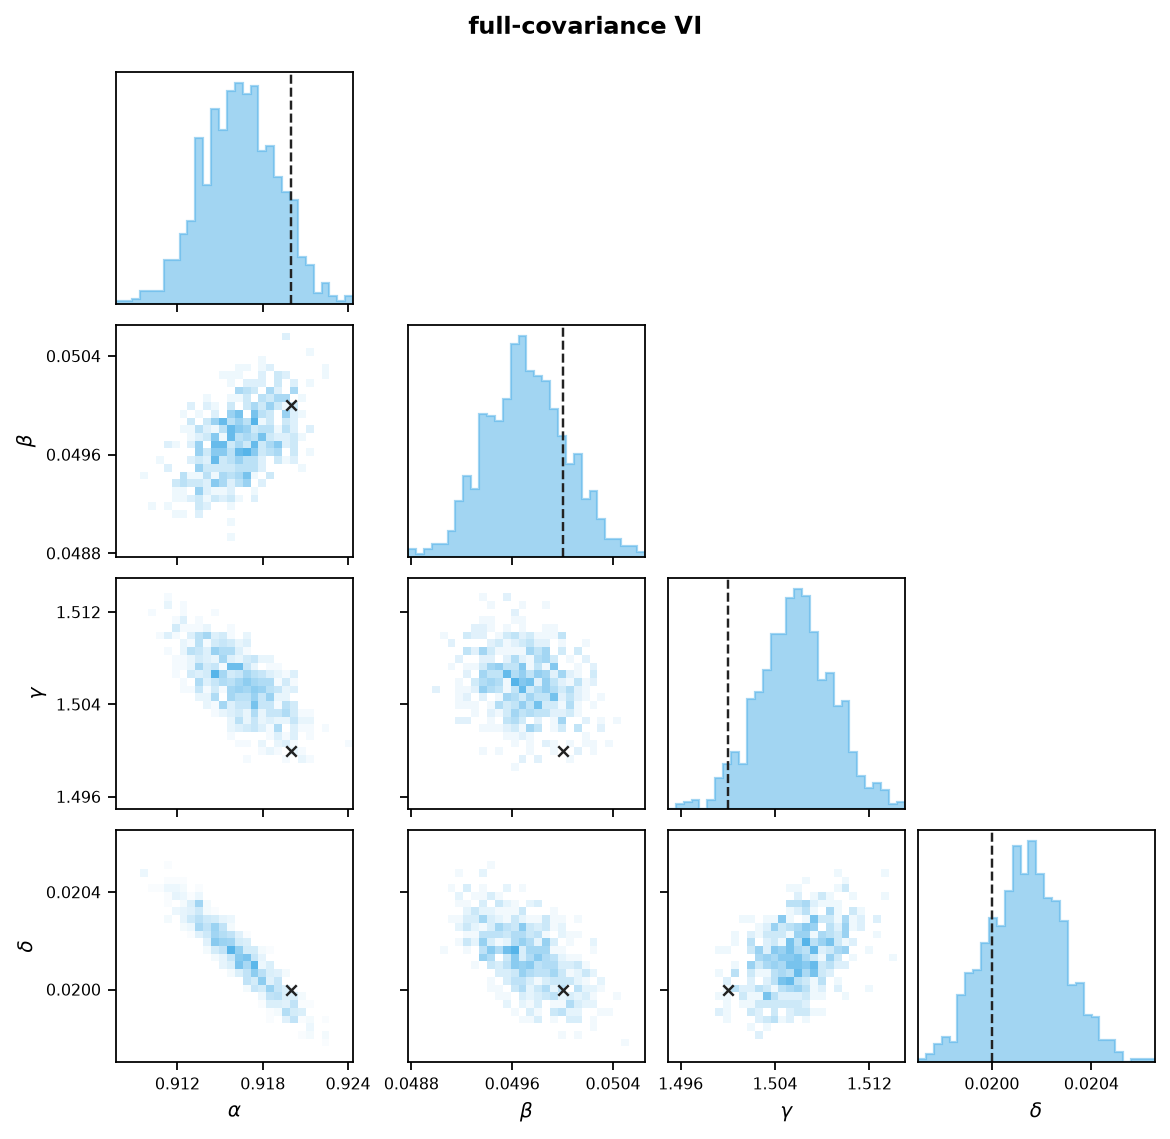

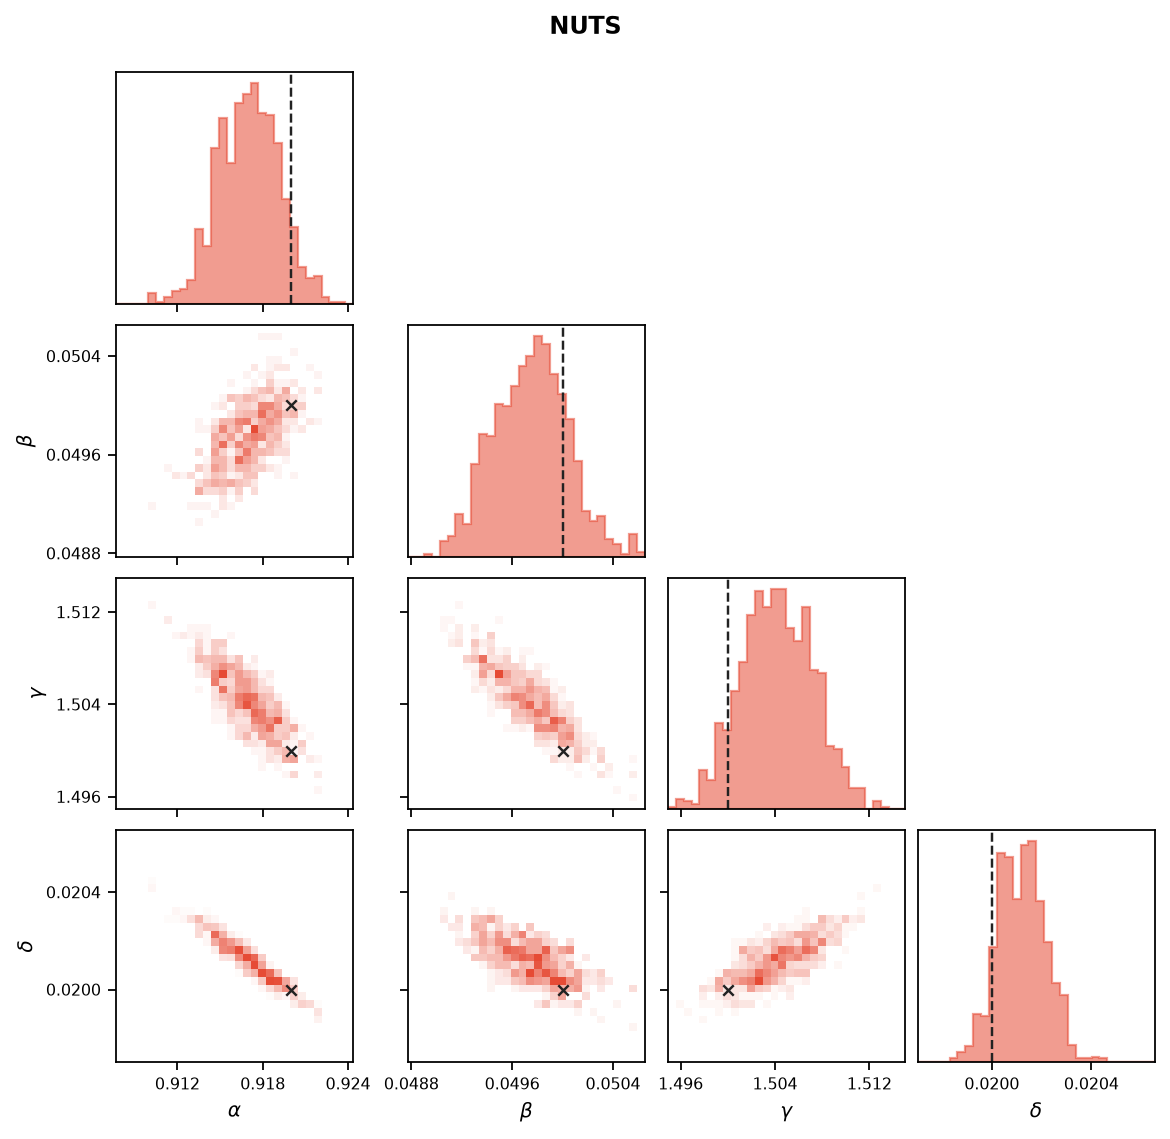

In [10]:
corner_draws = {
    "full-covariance VI": posterior_draws["full-covariance VI"],
    "NUTS": posterior_draws["NUTS"],
}
corner_n_draws = min(len(draws) for draws in corner_draws.values())
corner_draws = {
    method: draws[np.linspace(0, len(draws) - 1, corner_n_draws, dtype=int)]
    for method, draws in corner_draws.items()
}

all_corner_draws = np.concatenate(list(corner_draws.values()), axis=0)
corner_edges = [
    np.histogram_bin_edges(all_corner_draws[:, parameter], bins=30)
    for parameter in range(4)
]


def plot_corner(draws, method, color, output_stem):
    density_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        f"{output_stem}_density",
        ["#FFFFFF", color],
    )
    fig, axes = plt.subplots(4, 4, figsize=(7.2, 7.0), constrained_layout=True)
    fig.get_layout_engine().set(rect=(0.0, 0.0, 1.0, 0.95))

    for row in range(4):
        for col in range(4):
            ax = axes[row, col]
            if row < col:
                ax.axis("off")
                continue

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)
            ax.tick_params(direction="out", labelsize=7)
            ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
            ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))

            if row == col:
                ax.hist(
                    draws[:, col],
                    bins=corner_edges[col],
                    density=True,
                    histtype="stepfilled",
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.55,
                    linewidth=1.0,
                )
                ax.axvline(
                    float(true_parameters[col]),
                    color=STYLE_COLORS["black"],
                    linestyle="--",
                    linewidth=1.1,
                )
                ax.set_xlim(corner_edges[col][[0, -1]])
                ax.set_yticks([])
            else:
                ax.hist2d(
                    draws[:, col],
                    draws[:, row],
                    bins=(corner_edges[col], corner_edges[row]),
                    cmap=density_cmap,
                    cmin=1,
                    rasterized=True,
                )
                ax.scatter(
                    float(true_parameters[col]),
                    float(true_parameters[row]),
                    marker="x",
                    color=STYLE_COLORS["black"],
                    s=22,
                    linewidth=1.1,
                    zorder=3,
                )
                ax.set(
                    xlim=corner_edges[col][[0, -1]],
                    ylim=corner_edges[row][[0, -1]],
                )

            if row == 3:
                ax.set_xlabel(PARAMETER_NAMES[col])
            else:
                ax.tick_params(labelbottom=False)
            if col == 0 and row > 0:
                ax.set_ylabel(PARAMETER_NAMES[row])
            else:
                ax.tick_params(labelleft=False)

    fig.suptitle(method, fontsize=11, fontweight="bold", y=0.995)
    fig.savefig(f"outputs/{output_stem}.pdf")
    fig.savefig(f"outputs/{output_stem}.png", dpi=300)
    plt.show()


plot_corner(
    corner_draws["full-covariance VI"],
    "full-covariance VI",
    STYLE_COLORS["muted_blue"],
    "lotka_volterra_corner_vi",
)
plot_corner(
    corner_draws["NUTS"],
    "NUTS",
    STYLE_COLORS["warm_red"],
    "lotka_volterra_corner_nuts",
)

## Posterior predictive trajectories

Finally, we push evenly spaced posterior draws through `dsx.simulate`. Nested 50%, 80%, and 95% bands show uncertainty without letting one opaque interval dominate the trajectories.

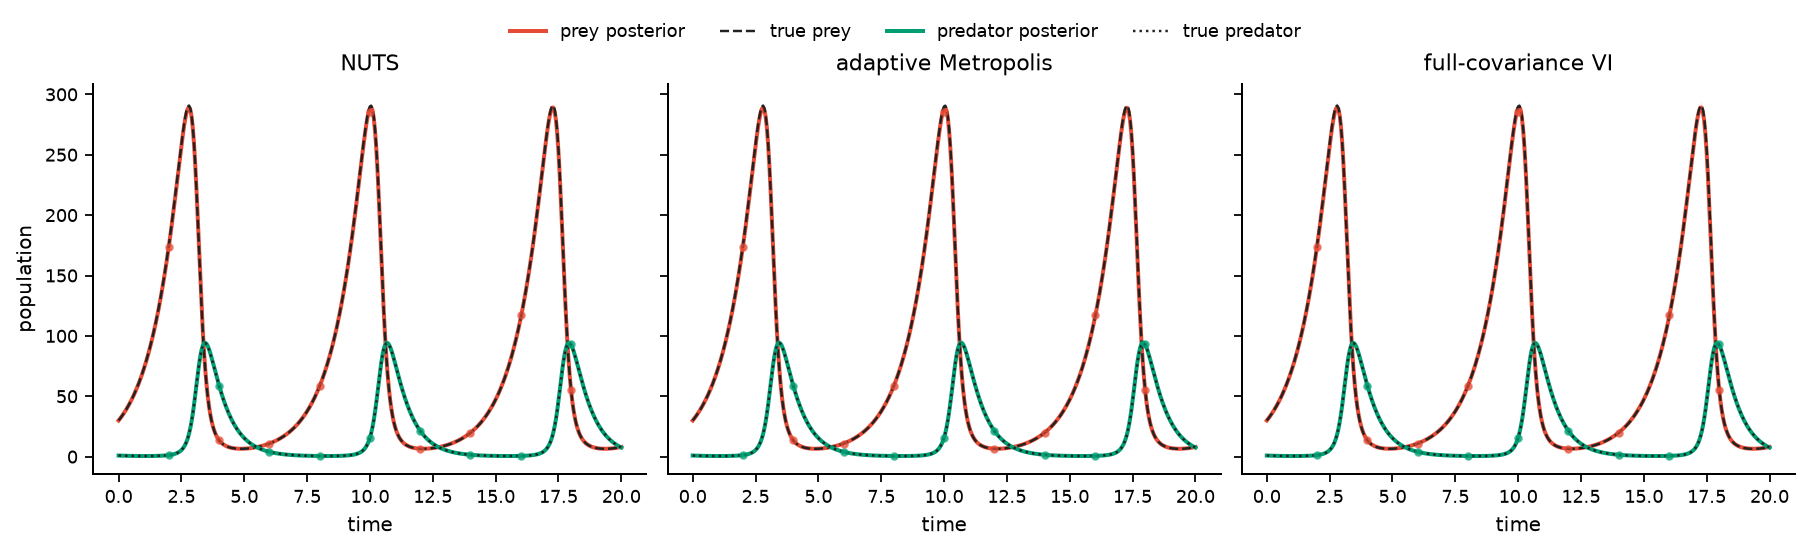

In [11]:
predictive_draws = 80


def select_evenly(draws, n_draws=predictive_draws):
    indices = np.linspace(0, len(draws) - 1, n_draws, dtype=int)
    return jnp.asarray(draws[indices])


def simulate_one_path(parameters, key):
    result = dsx.simulate(
        make_dynamics(parameters),
        rng_key=key,
        predict_times=plot_times,
        simulator_config=ODE_CONFIG,
    )
    return result.states[0]


simulate_paths = jax.jit(jax.vmap(simulate_one_path))
predictive_keys = jr.split(jr.PRNGKey(40), predictive_draws)
posterior_paths = {
    method: np.asarray(simulate_paths(select_evenly(draws), predictive_keys))
    for method, draws in posterior_draws.items()
}

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.1), sharex=True, sharey=True, constrained_layout=True)
for ax, (method, paths) in zip(axes, posterior_paths.items()):
    for state, label, color, truth_style in [
        (0, "prey", STYLE_COLORS["warm_red"], "--"),
        (1, "predator", STYLE_COLORS["teal"], ":"),
    ]:
        q025, q10, q25, median, q75, q90, q975 = np.percentile(
            paths[:, :, state],
            [2.5, 10, 25, 50, 75, 90, 97.5],
            axis=0,
        )
        ax.fill_between(plot_times, q025, q975, color=color, alpha=0.08, linewidth=0)
        ax.fill_between(plot_times, q10, q90, color=color, alpha=0.13, linewidth=0)
        ax.fill_between(plot_times, q25, q75, color=color, alpha=0.20, linewidth=0)
        ax.plot(plot_times, median, color=color, linewidth=1.8, label=f"{label} posterior")
        ax.plot(plot_times, truth[:, state], color=STYLE_COLORS["black"], linestyle=truth_style, linewidth=1.1, label=f"true {label}")
        ax.scatter(observation_times, observations[:, state], s=8, color=color, alpha=0.65, zorder=3)
    ax.set(title=method, xlabel="time")
    despine_curve_axis(ax)
axes[0].set_ylabel("population")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=4, loc="upper center", bbox_to_anchor=(0.5, 1.08))
fig.savefig("outputs/lotka_volterra_posterior_predictive.pdf")
fig.savefig("outputs/lotka_volterra_posterior_predictive.png", dpi=300)
plt.show()

## Takeaways

- One NumPyro model built with `dynestyx` defines the posterior for MAP, VI, NUTS, and adaptive Metropolis.
- `AutoDelta` with BFGS is a compact MAP estimator: one SVI update runs the optimizer to convergence, with no learning rate or training loop.
- `AutoMultivariateNormal` uses the same BFGS pattern to learn a dense Gaussian in the original log-parameter coordinates.
- `MCMCInference` handles sampler construction, warmup, parallel chains, constrained parameters, and compact diagnostics.
- Adaptive Metropolis freezes its learned proposal scales before retaining draws.

The short NUTS run is a computational reference, not a publication default. For a final analysis, increase retained draws, confirm $\hat R$ and tail ESS, repeat across seeds, and check sensitivity to the ODE tolerances.